# Trend Analysis (SMK) and Seasonality (GLSAR)

In [1]:
colour_1 = "#011428"
colour_2 = "#e8762a"
colour_3 = "#6a86aa"

In [10]:
import math
import pandas as pd
import numpy as np
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

from shapely.geometry import box
from statsmodels.tsa.seasonal import STL
from matplotlib.ticker import MaxNLocator
from pyproj import Transformer
from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [3]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)

In [22]:
def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    s = s.resample('MS').mean()
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

GOWN = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)

marmot_creek_wells = ['0931', '0301', '0303', '0386', '0305']
canmore_wells = ['0764', '0760', '0759', '0364']

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

In [5]:
order = sorted(df_m.columns)
z = (df_m - df_m.mean()) / df_m.std()

In [11]:
coords = pd.read_csv(GOWN / 'tables' / 'stations.csv', usecols=[3, 5, 6], index_col=0)

In [12]:
def var_fractions(s, period=12):
    r = STL(s, period=period, robust=True).fit()
    v = {"trend": r.trend.var(), "seasonal": r.seasonal.var(), "resid": r.resid.var()}
    tot = sum(v.values())
    return {k: x / tot for k, x in v.items()}

In [13]:
frac = pd.DataFrame({w: var_fractions(df_m[w]) for w in df_m.columns}).T

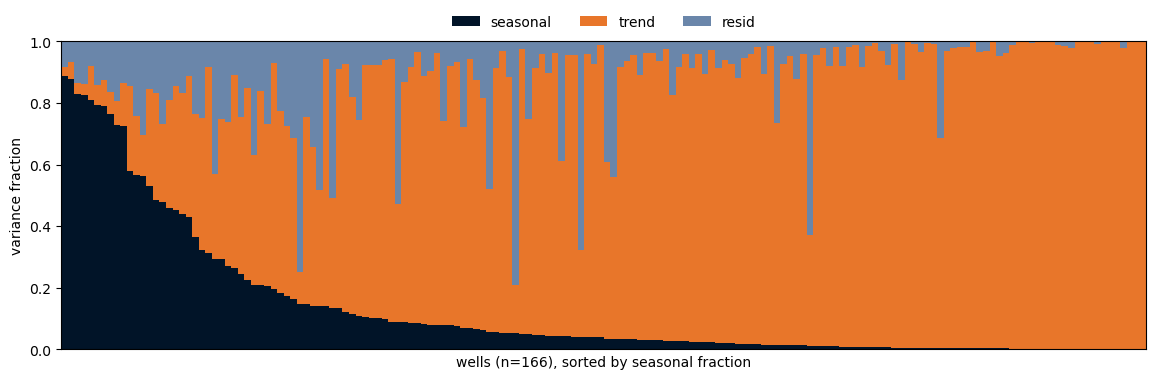

In [14]:
order = frac.sort_values("seasonal", ascending=False).index
fp = frac.loc[order]

fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(fp))
colors = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}
for comp in ["seasonal", "trend", "resid"]:
    ax.bar(range(len(fp)), fp[comp], bottom=bottom, width=1.0,
           color=colors[comp], label=comp, edgecolor="none")
    bottom += fp[comp].values

ax.set_xlim(-0.5, len(fp)-0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_xlabel(f"wells (n={len(fp)}), sorted by seasonal fraction")
ax.set_ylabel("variance fraction")
ax.legend(ncol=3, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0))

(np.float64(-0.05),
 np.float64(1.05),
 np.float64(-0.04330127018922193),
 np.float64(0.9093266739736605))

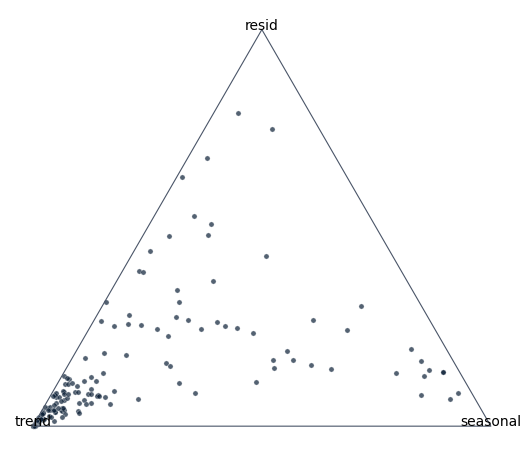

In [15]:
# barycentric -> 2D
t, s, r = frac["trend"], frac["seasonal"], frac["resid"]
x = 0.5 * (2*s + r)          # corners: trend=(0,0), seasonal=(1,0), resid=(0.5,√3/2)
y = (np.sqrt(3)/2) * r

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(x, y, s=14, c="#0b1f36", alpha=0.7, edgecolor="w", lw=0.3)
# triangle frame
tri = np.array([[0,0], [1,0], [0.5, np.sqrt(3)/2], [0,0]])
ax.plot(tri[:,0], tri[:,1], color="#4a5568", lw=0.8)
for (px,py),lab in zip(tri[:3], ["trend","seasonal","resid"]):
    ax.annotate(lab, (px,py), fontsize=10, ha="center")
ax.set_aspect("equal"); ax.axis("off")

In [16]:
comps, fits = {}, {}
for w in df_m.columns:
    r = STL(df_m[w], period=12, robust=True).fit()
    sd = df_m[w].std()
    fits[w] = r
    comps[w] = {"trend": (r.trend - r.trend.mean()) / sd,
                "seasonal": r.seasonal / sd,
                "resid": r.resid / sd}

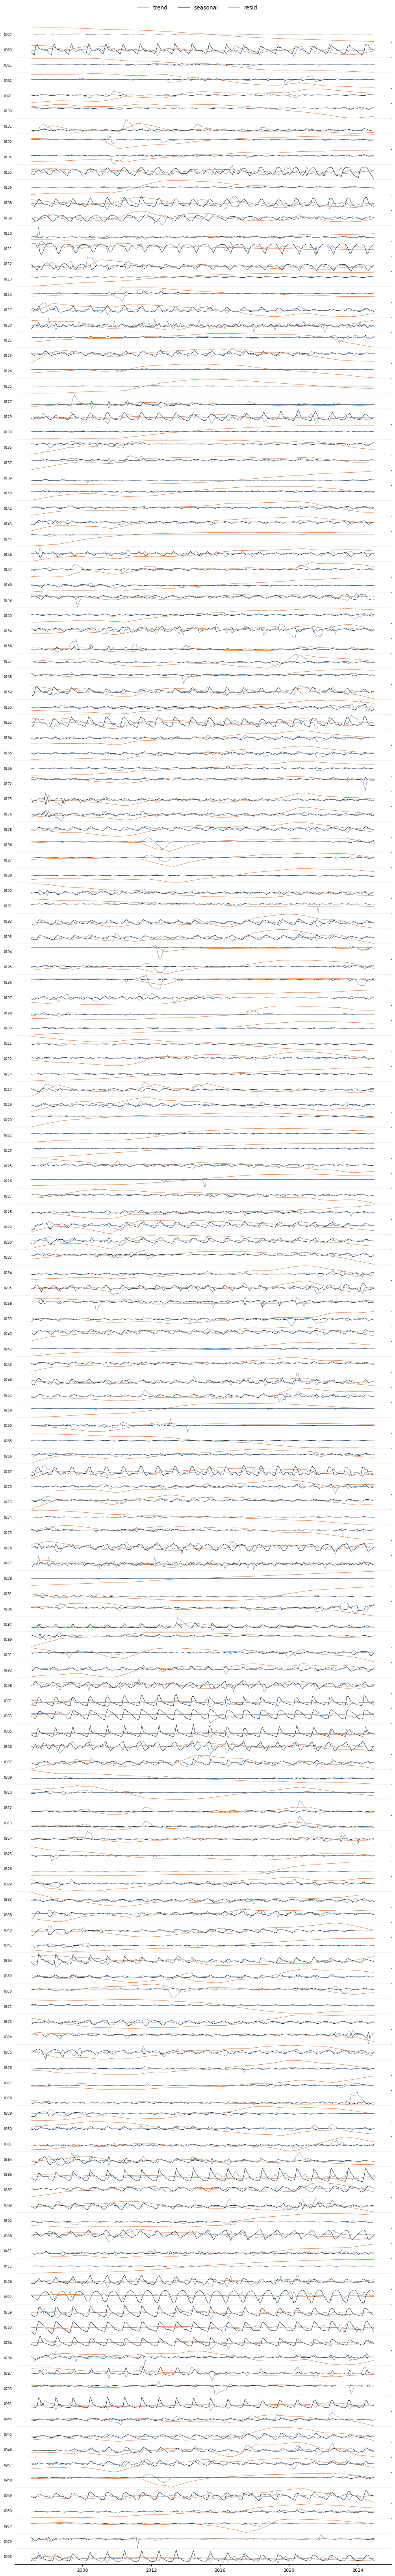

In [17]:
order = sorted(df_m.columns)

C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

n = len(order)
fig, axes = plt.subplots(n, 1, figsize=(11, n*0.4), sharex=True, sharey=False)

for ax, w in zip(axes, order):
    for comp in ("trend", "seasonal", "resid"):
        ax.plot(df_m.index, comps[w][comp], lw=0.6, color=C[comp])
    ax.set_ylabel(w, rotation=0, ha="right", va="center", fontsize=6)
    ax.set_yticks([])
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

axes[-1].tick_params(labelsize=8)
handles = [plt.Line2D([], [], color=C[k], lw=1.5, label=k) for k in C]
fig.legend(handles=handles, ncol=3, frameon=False, loc="upper center")
fig.subplots_adjust(hspace=0, left=0.12, right=0.99, top=0.99, bottom=0.02)
plt.show()

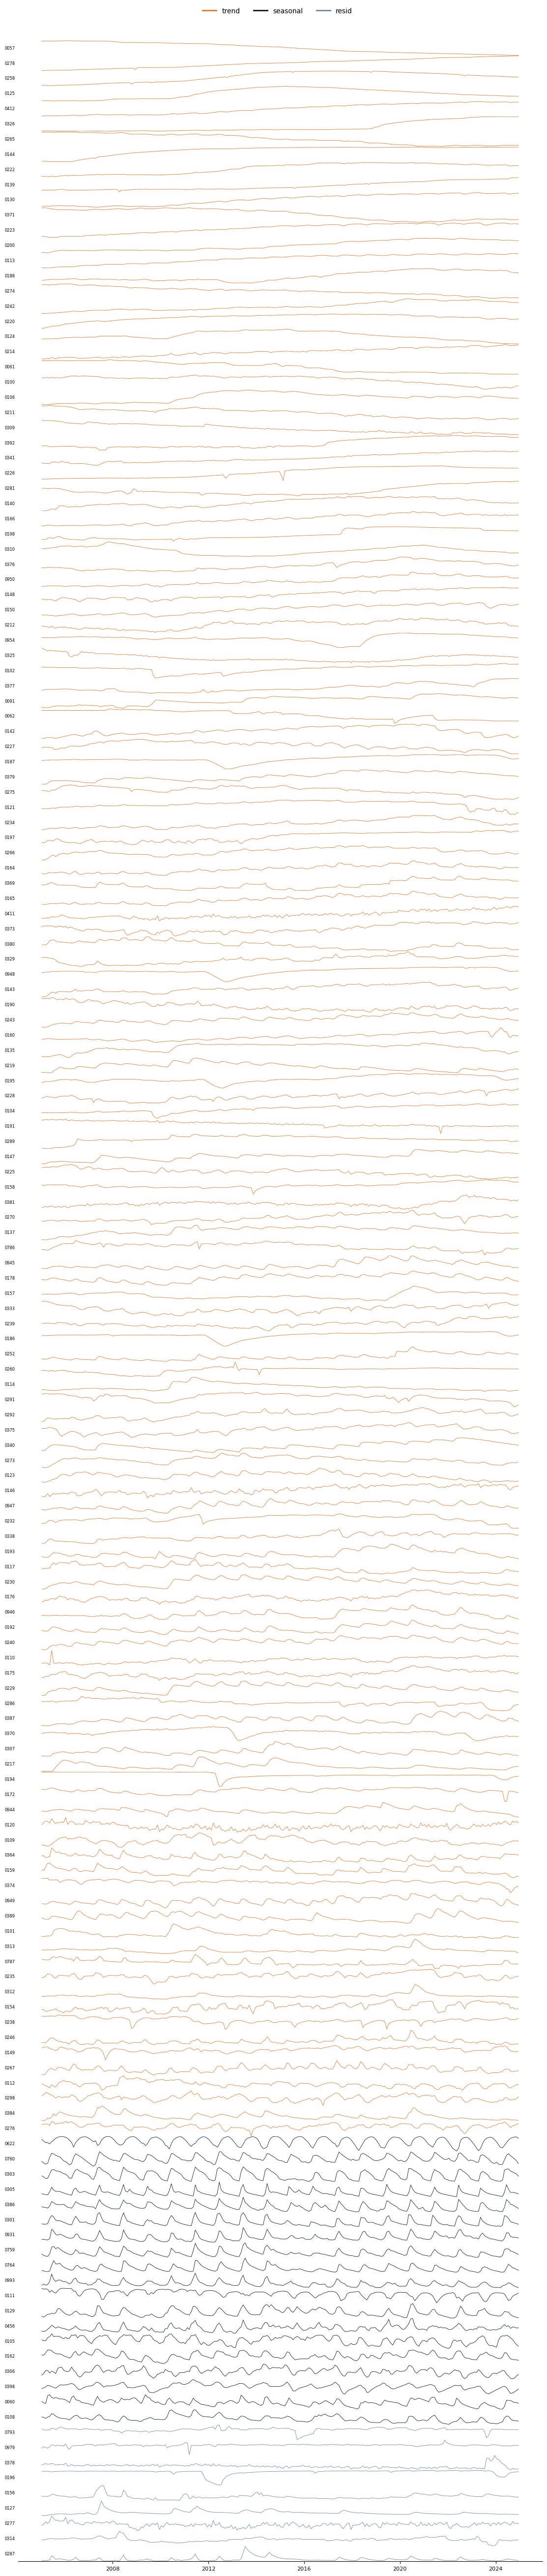

In [18]:
dom = frac.idxmax(axis=1)                          # dominant component per well

order, boundaries, cursor = [], [], 0
for comp in ("trend", "seasonal", "resid"):
    members = frac.loc[dom == comp, comp].sort_values(ascending=False).index
    order.extend(members)
    cursor += len(members)
    boundaries.append((comp, cursor, len(members)))

n = len(order)
fig, axes = plt.subplots(n, 1, figsize=(11, n*0.32), sharex=True, sharey=False)
C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

for ax, w in zip(axes, order):
    ax.plot(df_m.index, z[w], lw=0.6, color=C[dom[w]])   # color encodes the group
    ax.set_ylabel(w, rotation=0, ha="right", va="center", fontsize=6)
    ax.set_yticks([])
    ax.margins(y=0.02)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)


axes[-1].tick_params(labelsize=8)
axes[-1].spines["bottom"].set_visible(True)

handles = [plt.Line2D([], [], color=C[k], lw=2, label=k) for k in C]
fig.legend(handles=handles, ncol=3, frameon=False, loc="upper center",
           bbox_to_anchor=(0.5, 1.0), fontsize=10)

fig.subplots_adjust(hspace=0, left=0.02, right=0.99, top=0.985, bottom=0.02)
plt.show()

In [19]:
from matplotlib.backends.backend_pdf import PdfPages

/tmp/ipykernel_43218/3421221552.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


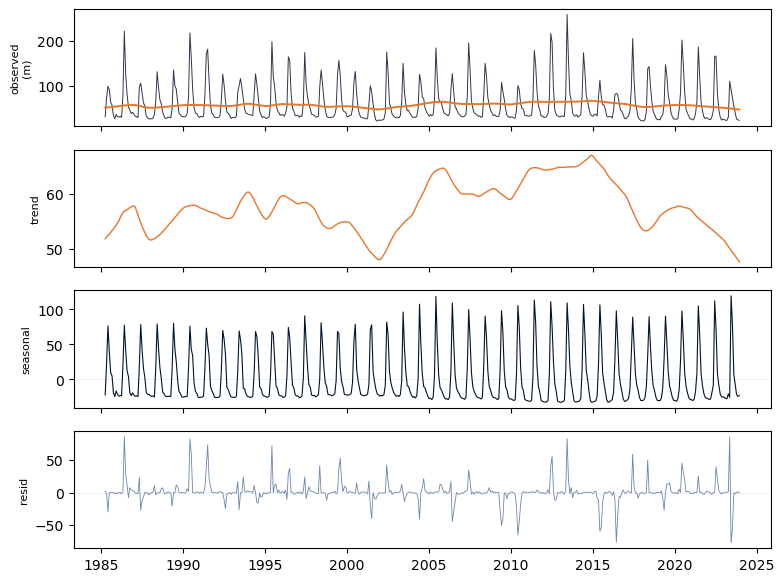

In [23]:
r = STL(brac, period=12, robust=True).fit()
sd = brac.std()
fit = r
comp = {"trend": (r.trend - r.trend.mean()) / sd,
        "seasonal": r.seasonal / sd,
        "resid": r.resid / sd}

fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

axes[0].plot(brac.index, brac, lw=0.7, color="#2d3748")
axes[0].plot(brac.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
axes[0].set_ylabel("observed\n(m)", fontsize=8)

axes[1].plot(brac.index, r.trend, lw=1.0, color=C["trend"])
axes[1].set_ylabel("trend", fontsize=8)

axes[2].plot(brac.index, r.seasonal, lw=0.8, color=C["seasonal"])
axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[2].set_ylabel("seasonal", fontsize=8)

axes[3].plot(brac.index, r.resid, lw=0.6, color=C["resid"])
axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[3].set_ylabel("resid", fontsize=8)

fig.show()

/tmp/ipykernel_43218/719715858.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


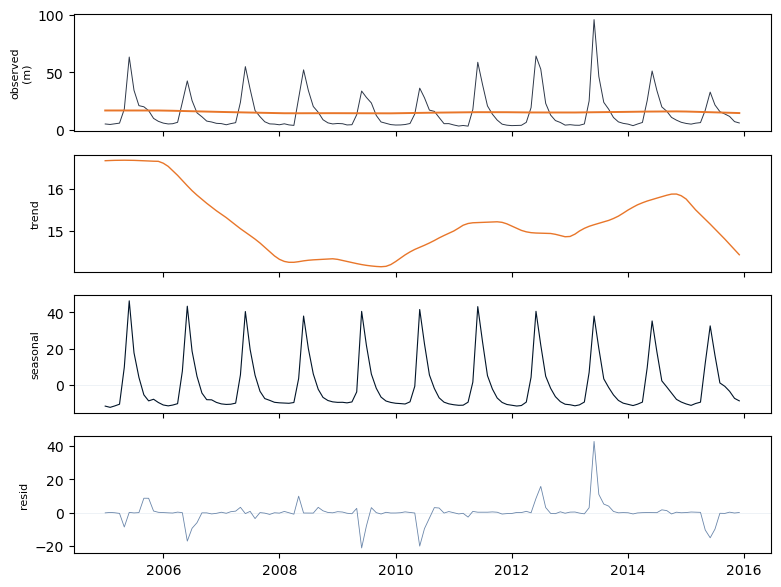

In [24]:
r = STL(krns, period=12, robust=True).fit()
sd = krns.std()
fit = r
comp = {"trend": (r.trend - r.trend.mean()) / sd,
        "seasonal": r.seasonal / sd,
        "resid": r.resid / sd}

fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

axes[0].plot(krns.index, krns, lw=0.7, color="#2d3748")
axes[0].plot(krns.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
axes[0].set_ylabel("observed\n(m)", fontsize=8)

axes[1].plot(krns.index, r.trend, lw=1.0, color=C["trend"])
axes[1].set_ylabel("trend", fontsize=8)

axes[2].plot(krns.index, r.seasonal, lw=0.8, color=C["seasonal"])
axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[2].set_ylabel("seasonal", fontsize=8)

axes[3].plot(krns.index, r.resid, lw=0.6, color=C["resid"])
axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[3].set_ylabel("resid", fontsize=8)

fig.show()

In [ ]:
# dom = frac.idxmax(axis=1)
# C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

# # walk trend wells -> seasonal -> resid, purest first within each group
# order = []
# for comp in ("trend", "seasonal", "resid"):
#     order.extend(frac.loc[dom == comp, comp].sort_values(ascending=False).index)

# with PdfPages("stl_all_wells.pdf") as pdf:
#     for w in order:
#         r = fits[w]
#         fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

#         axes[0].plot(df_m.index, df_m[w], lw=0.7, color="#2d3748")
#         axes[0].plot(df_m.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
#         axes[0].set_ylabel("observed\n(m)", fontsize=8)

#         axes[1].plot(df_m.index, r.trend, lw=1.0, color=C["trend"])
#         axes[1].set_ylabel("trend", fontsize=8)

#         axes[2].plot(df_m.index, r.seasonal, lw=0.8, color=C["seasonal"])
#         axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
#         axes[2].set_ylabel("seasonal", fontsize=8)

#         axes[3].plot(df_m.index, r.resid, lw=0.6, color=C["resid"])
#         axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
#         axes[3].set_ylabel("resid", fontsize=8)

#         for ax in axes:
#             ax.tick_params(labelsize=7)
#             for s in ("top", "right"):
#                 ax.spines[s].set_visible(False)

#         f = frac.loc[w]
#         fig.suptitle(
#             f"{w}   ·   trend {f['trend']:.2f}   seasonal {f['seasonal']:.2f}   resid {f['resid']:.2f}"
#             f"   ·   dominant: {dom[w]}",
#             fontsize=10, color=C[dom[w]], y=0.98)
#         fig.subplots_adjust(hspace=0.12, left=0.10, right=0.98, top=0.93, bottom=0.06)

#         pdf.savefig(fig)
#         plt.close(fig)

### Inter-annual variations on trend and residual components of STL

In [25]:
iav_trend = pd.Series({w: fits[w].trend.std() for w in df_m.columns})

In [26]:
resid_ann = pd.DataFrame({w: fits[w].resid for w in df_m.columns}).resample("YS").mean()
iav_anom = resid_ann.std()

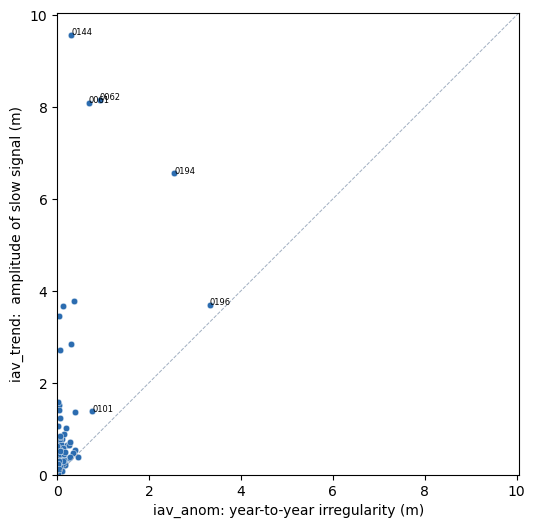

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(iav_anom, iav_trend, s=22, c="#2b6cb0", edgecolor="w", lw=0.3)

lim = max(iav_trend.max(), iav_anom.max()) * 1.05
ax.plot([0, lim], [0, lim], lw=0.7, ls="--", color="#a0aec0")   # y = x
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_xlabel("iav_anom: year-to-year irregularity (m)")
ax.set_ylabel("iav_trend:  amplitude of slow signal (m)")

for w in iav_trend.nlargest(4).index.union(iav_anom.nlargest(4).index):
    ax.annotate(w, (iav_anom[w], iav_trend[w]), fontsize=6)

## Harmonic Regression

In [28]:
import statsmodels.api as sm

In [ ]:
t = np.arange(len(df_m))
X = sm.add_constant(pd.DataFrame({
    "t":   t,
    "cos": np.cos(2*np.pi*t/12),
    "sin": np.sin(2*np.pi*t/12),
}, index=df_m.index))

In [30]:
X

,const,t,cos,sin
date,,,,
2005-01-15,1.0,0,1.000000e+00,0.000000
2005-02-15,1.0,1,8.660254e-01,0.500000
2005-03-15,1.0,2,5.000000e-01,0.866025
2005-04-15,1.0,3,6.123234e-17,1.000000
2005-05-15,1.0,4,-5.000000e-01,0.866025
...,...,...,...,...
2024-08-15,1.0,235,-8.660254e-01,-0.500000
2024-09-15,1.0,236,-5.000000e-01,-0.866025
2024-10-15,1.0,237,-1.371914e-14,-1.000000


- Jan - 0
- Dec - 2*pi = 6.2

In [31]:
it, ia, ib = (X.columns.get_loc(k) for k in ("t", "cos", "sin"))
R = np.zeros((2, X.shape[1]))
R[0, ia] = 1
R[1, ib] = 1     # H0: a = b = 0

In [32]:
print(it, ia, ib)

1 2 3


In [33]:
R

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.]])

- df_m[w]: per well time-series (dependent variable)
- X: 1 intercept (`const`) + 3 regressors (`t`, `cos`, `sin`)
- rho: order of autoregressive covariance

Fitting:
$$y_t = \beta_0 + \beta_1 t + \beta_2\cos\!\Big(\tfrac{2\pi t}{12}\Big) + \beta_3\sin\!\Big(\tfrac{2\pi t}{12}\Big) + \varepsilon_t​
$$

Plain OLS assumes $\varepsilon_t$ are i.i.d. noise. GLSAR instead assumes the errors themselves follow an AR(1) process:
$$\varepsilon_t = \rho\,\varepsilon_{t-1} + \eta_t, \qquad \eta_t \sim \text{i.i.d. noise}$$

In [34]:
rows = {}
for w in df_m.columns:
    mod = sm.GLSAR(df_m[w].values, X.values, rho=1)
    res = mod.iterative_fit(maxiter=10)
    a, b = res.params[ia], res.params[ib]
    seas = a*np.cos(2*np.pi*t/12) + b*np.sin(2*np.pi*t/12)
    rows[w] = {
        "slope_m_yr": res.params[it] * 12,
        "slope_se":   res.bse[it] * 12,
        "amp_pp":     2*np.hypot(a, b),                    # peak-to-peak, metres
        "phase_rad":  np.arctan2(b, a),
        "peak_month": pd.Series(seas, index=df_m.index)
                        .groupby(df_m.index.month).mean().idxmax(),
        "rho":        mod.rho[0],
        "resid_sd":   np.std(res.resid),
        "seas_p":     float(res.f_test(R).pvalue),
    }
harm = pd.DataFrame(rows).T
harm["snr"] = harm["amp_pp"] / harm["resid_sd"]

<Axes: >

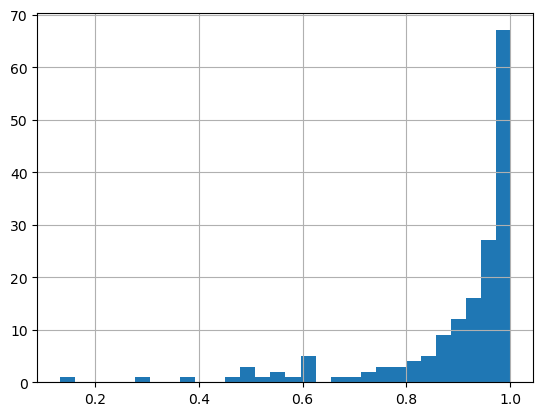

In [35]:
harm['rho'].hist(bins=30)

In [36]:
harm

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
0057,-0.631759,0.018736,0.087128,-0.611503,12.0,0.974444,0.533395,2.067698e-07,0.163347
0060,-0.032201,0.010987,0.578646,3.107560,7.0,0.724525,0.385398,2.969742e-08,1.501422
0061,-1.463001,0.163698,0.228073,-2.911870,7.0,0.974582,2.072352,2.273572e-01,0.110055
0062,-1.422459,0.191953,0.209142,1.237499,3.0,0.943378,3.016890,8.364506e-01,0.069324
0091,-0.073320,0.093640,0.164257,-1.294297,11.0,0.993401,1.026197,3.272771e-14,0.160063
...,...,...,...,...,...,...,...,...,...
0949,0.026547,0.012780,0.518545,-2.817836,8.0,0.878276,0.293402,1.344809e-19,1.767356
0950,0.036573,0.007383,0.053848,2.668569,6.0,0.963979,0.093828,7.999152e-09,0.573903
0954,0.084398,0.249573,0.059928,1.777170,4.0,0.995796,0.944782,1.955229e-01,0.063430
0979,0.001758,0.001211,0.059765,-0.837816,11.0,0.289673,0.080429,5.471754e-03,0.743079


In [51]:
streams = {"krns": krns, "bl": bl, "lkl": lkl,
           "brac_e": brac_e, "brab": brab, "brac": brac}

rows = {}
for name, stream in streams.items():
    s = stream.dropna()
    t = np.arange(len(s))
    X = sm.add_constant(pd.DataFrame({
        "t":   t,
        "cos": np.cos(2*np.pi*t/12),
        "sin": np.sin(2*np.pi*t/12),
    }, index=s.index))

    it, ia, ib = (X.columns.get_loc(k) for k in ("t", "cos", "sin"))
    R = np.zeros((2, X.shape[1]))
    R[0, ia] = 1
    R[1, ib] = 1     # H0: a = b = 0

    mod = sm.GLSAR(s.values, X.values, rho=1)
    res = mod.iterative_fit(maxiter=10)
    a, b = res.params[ia], res.params[ib]
    seas = a*np.cos(2*np.pi*t/12) + b*np.sin(2*np.pi*t/12)
    rows[name] = {
        "slope_m_yr": res.params[it] * 12,
        "slope_se":   res.bse[it] * 12,
        "amp_pp":     2*np.hypot(a, b),                    # peak-to-peak, metres
        "phase_rad":  np.arctan2(b, a),
        "peak_month": pd.Series(seas, index=s.index)
                        .groupby(s.index.month).mean().idxmax(),
        "rho":        mod.rho[0],
        "resid_sd":   np.std(res.resid),
        "seas_p":     float(res.f_test(R).pvalue),
    }

harm_stream = pd.DataFrame(rows).T
harm_stream["snr"] = harm_stream["amp_pp"] / harm_stream["resid_sd"]

In [52]:
harm_stream

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
krns,0.118089,0.391331,32.665299,2.983016,7.0,0.263325,10.557525,1.300134e-16,3.094030
bl,-0.009371,0.084319,28.469858,-1.192645,7.0,0.306141,8.688200,2.530853e-43,3.276842
lkl,0.075734,0.015458,7.087207,-2.277917,11.0,0.831489,3.143040,1.580907e-83,2.254889
brac_e,-0.001248,0.002161,0.566001,3.003849,7.0,0.367111,0.149250,1.658127e-40,3.792305
brab,-0.000903,0.004275,0.833095,-3.086417,7.0,0.308708,0.168306,1.056583e-39,4.949876
brac,-0.034345,0.160592,88.392570,1.398273,7.0,0.319303,27.632213,1.358632e-58,3.198896


Text(5, 5, '0091')

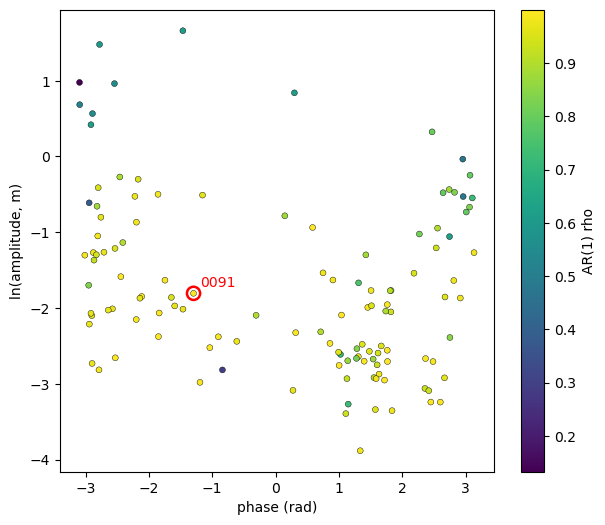

In [37]:
sig = harm[harm["seas_p"] < 0.01].copy()          # keep only wells with a real cycle
sig["ln_amp"] = np.log(sig["amp_pp"])

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sig["phase_rad"], sig["ln_amp"], s=18, c=sig["rho"],
                 cmap="viridis", edgecolor="k", lw=0.3)
plt.colorbar(sc, label="AR(1) rho")
ax.set_xlabel("phase (rad)"); ax.set_ylabel("ln(amplitude, m)")

w = "0091"
ax.scatter(harm.loc[w,"phase_rad"], np.log(harm.loc[w,"amp_pp"]),
           s=90, facecolor="none", edgecolor="red", lw=1.8)
ax.annotate(w, (harm.loc[w,"phase_rad"], np.log(harm.loc[w,"amp_pp"])),
            xytext=(5,5), textcoords="offset points", color="red")

In [38]:
sig

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr,ln_amp
0057,-0.631759,0.018736,0.087128,-0.611503,12.0,0.974444,0.533395,2.067698e-07,0.163347,-2.440373
0060,-0.032201,0.010987,0.578646,3.107560,7.0,0.724525,0.385398,2.969742e-08,1.501422,-0.547065
0091,-0.073320,0.093640,0.164257,-1.294297,11.0,0.993401,1.026197,3.272771e-14,0.160063,-1.806326
0101,-0.253429,0.119908,0.662752,-2.799433,8.0,0.947502,1.826195,5.164985e-03,0.362914,-0.411354
0102,0.055417,0.021333,0.056558,1.635130,4.0,0.980799,0.268986,1.109791e-04,0.210262,-2.872495
...,...,...,...,...,...,...,...,...,...,...
0947,0.025246,0.039366,0.448505,-2.757230,8.0,0.963403,0.474934,4.392742e-18,0.944352,-0.801836
0949,0.026547,0.012780,0.518545,-2.817836,8.0,0.878276,0.293402,1.344809e-19,1.767356,-0.656728
0950,0.036573,0.007383,0.053848,2.668569,6.0,0.963979,0.093828,7.999152e-09,0.573903,-2.921584
0979,0.001758,0.001211,0.059765,-0.837816,11.0,0.289673,0.080429,5.471754e-03,0.743079,-2.817339


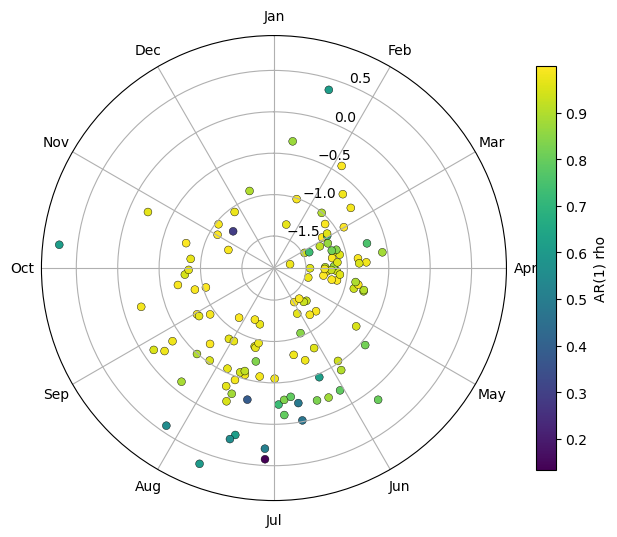

In [39]:
sig = harm[harm["seas_p"] < 0.01].copy()
sig["peak_t"] = (12 * sig["phase_rad"] / (2*np.pi)) % 12   # continuous, 0 = Jan 1

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
sc = ax.scatter(2*np.pi*sig["peak_t"]/12, np.log10(sig["amp_pp"]),
                s=32, c=sig["rho"], cmap="viridis", edgecolor="k", lw=0.3)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_xticks(np.arange(12)*2*np.pi/12)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_rlim(np.log10(sig["amp_pp"]).min()-0.2, np.log10(sig["amp_pp"]).max()+0.2)
plt.colorbar(sc, label="AR(1) rho", shrink=0.7)

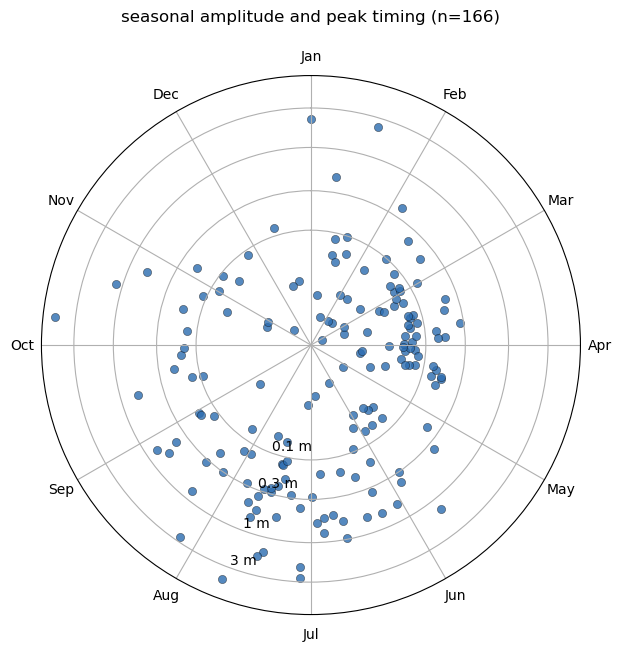

In [40]:
angle = harm["phase_rad"] % (2*np.pi)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.scatter(angle, np.log10(harm["amp_pp"]), s=35, c="#2b6cb0",
           edgecolor="k", lw=0.3, alpha=0.8)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(np.arange(12) * 2*np.pi/12)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])

ticks = [0.1, 0.3, 1, 3]
ax.set_rticks(np.log10(ticks))
ax.set_yticklabels([f"{v} m" for v in ticks])
ax.set_rlabel_position(200)
ax.set_title(f"seasonal amplitude and peak timing (n={len(harm)})", pad=20)
plt.show()

In [41]:
coords.rename(columns={'latitude': 'lat', 'longitude': 'lon'}, inplace=True)

In [42]:
out = harm[["amp_pp", "phase_rad", "peak_month", "rho", "snr", "seas_p"]].copy()
out["seas_sig"] = out["seas_p"] < 0.01
out["phase_deg"] = ((12 * out["phase_rad"] / (2*np.pi)) % 12) / 12 * 360
out = out.join(coords[["lat", "lon"]])
out.index.name = "station"
# out.round(4).to_csv("harmonic_regression_features.csv")

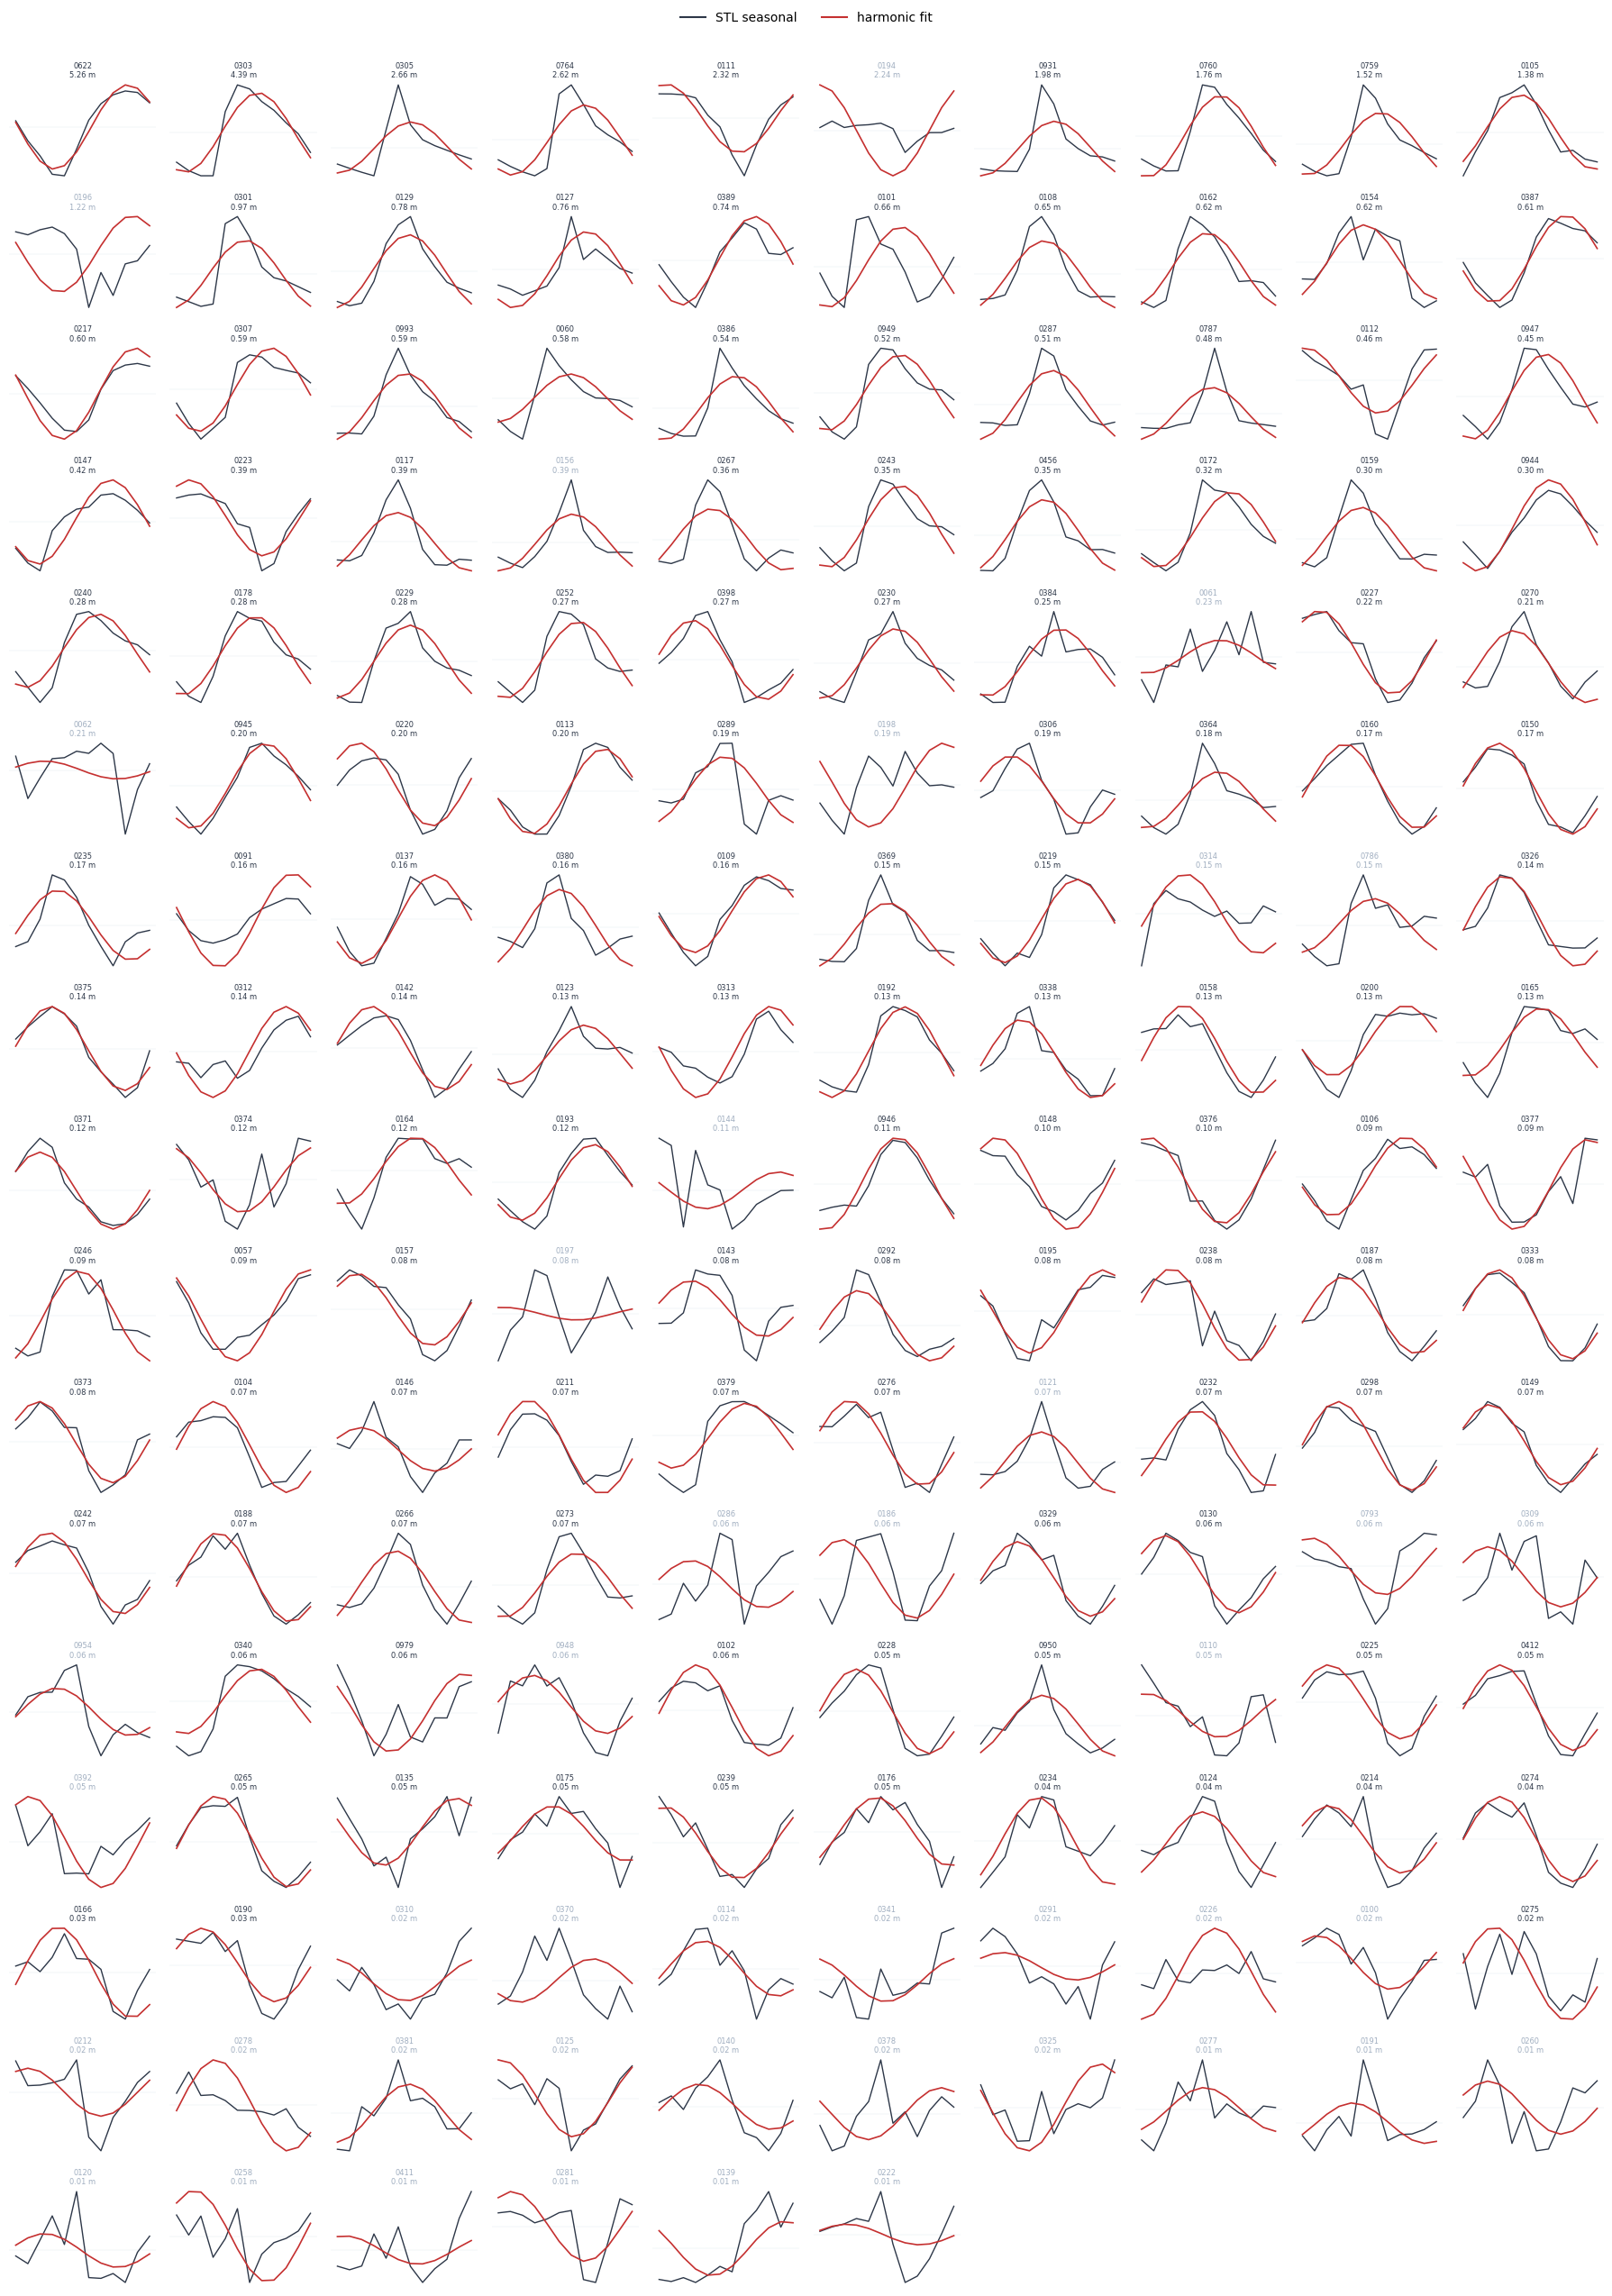

In [43]:
import math

t = np.arange(len(df_m))
order = harm.sort_values("amp_pp", ascending=False).index

n = len(order)
ncols = 10
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.5))
axes = axes.flatten()

for ax, w in zip(axes, order):
    # STL seasonal, averaged across the 20 years -> mean annual cycle
    s = fits[w].seasonal
    stl_cycle = s.groupby(s.index.month).mean()

    # harmonic fit, rebuilt from amp_pp and phase, folded the same way
    A, phi = harm.loc[w, "amp_pp"] / 2, harm.loc[w, "phase_rad"]
    fit = pd.Series(A * np.cos(2*np.pi*t/12 - phi), index=df_m.index)
    fit_cycle = fit.groupby(df_m.index.month).mean()

    ax.plot(stl_cycle.index, stl_cycle.values, lw=1.0, color="#2d3748")
    ax.plot(fit_cycle.index, fit_cycle.values, lw=1.2, color="#c53030")
    ax.axhline(0, lw=0.3, color="#e2e8f0", zorder=0)

    ok = harm.loc[w, "seas_p"] < 0.01
    ax.set_title(f"{w}\n{harm.loc[w, 'amp_pp']:.2f} m", fontsize=6, pad=2,
                 color="#2d3748" if ok else "#a0aec0")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ("top", "right", "left", "bottom"):
        ax.spines[sp].set_visible(False)

for ax in axes[n:]:
    ax.axis("off")

fig.legend(handles=[plt.Line2D([], [], color="#2d3748", lw=1.5, label="STL seasonal"),
                    plt.Line2D([], [], color="#c53030", lw=1.5, label="harmonic fit")],
           ncol=2, frameon=False, loc="upper center")
plt.tight_layout(rect=[0, 0, 1, 0.98])
# fig.savefig("harmonic_fit_examples.pdf", dpi=400, bbox_inches="tight")
plt.show()

## Seasonal MK

In [53]:
import pymannkendall as mk

explicity show seasonal correlation, to justify using this method

In [54]:
rows = {}
for w in df_m.columns:
    r = mk.correlated_seasonal_test(df_m[w].values, period=12)
    rows[w] = {"tau": r.Tau, "slope_m_yr": r.slope, "p": r.p, "verdict": r.trend}

smk = pd.DataFrame(rows).T
smk[["tau", "slope_m_yr", "p"]] = smk[["tau", "slope_m_yr", "p"]].astype(float)

print(smk["verdict"].value_counts())

verdict
increasing    73
no trend      50
decreasing    43
Name: count, dtype: int64


In [55]:
sen = smk.sort_values("slope_m_yr")
print("strongest declines:\n", sen[["slope_m_yr", "tau", "p"]].head(5))
print("\nstrongest rises:\n", sen[["slope_m_yr", "tau", "p"]].tail(5))
print(f"\n{(smk['p'] < 0.05).sum()} of {len(smk)} 'significant' at p<0.05")

strongest declines:
       slope_m_yr       tau             p
0061   -1.365273 -0.903509  1.958160e-08
0062   -1.335943 -0.810526  3.775539e-07
0194   -0.742030 -0.328947  3.039111e-02
0057   -0.590100 -0.992982  9.124306e-10
0309   -0.217903 -0.920175  9.828199e-09

strongest rises:
       slope_m_yr       tau             p
0326    0.421087  0.939474  5.660944e-09
0197    0.440817  0.806140  2.080077e-07
0223    0.474560  0.918421  8.447794e-09
0198    0.515238  0.676316  2.027925e-05
0144    0.847642  0.859649  7.635558e-08

116 of 166 'significant' at p<0.05


In [56]:
smk.sort_values("slope_m_yr")

,tau,slope_m_yr,p,verdict
0061,-0.903509,-1.365273,1.958160e-08,decreasing
0062,-0.810526,-1.335943,3.775539e-07,decreasing
0194,-0.328947,-0.742030,3.039111e-02,decreasing
0057,-0.992982,-0.590100,9.124306e-10,decreasing
0309,-0.920175,-0.217903,9.828199e-09,decreasing
...,...,...,...,...
0326,0.939474,0.421087,5.660944e-09,increasing
0197,0.806140,0.440817,2.080077e-07,increasing
0223,0.918421,0.474560,8.447794e-09,increasing
0198,0.676316,0.515238,2.027925e-05,increasing


In [57]:
smk.index = pd.to_numeric(smk.index, errors='coerce')
smk

,tau,slope_m_yr,p,verdict
57,-0.992982,-0.590100,9.124306e-10,decreasing
60,-0.377193,-0.034794,1.158076e-03,decreasing
61,-0.903509,-1.365273,1.958160e-08,decreasing
62,-0.810526,-1.335943,3.775539e-07,decreasing
91,0.650877,0.097235,2.676208e-05,increasing
...,...,...,...,...
949,0.390351,0.030953,5.302985e-03,increasing
950,0.796491,0.038894,5.393499e-07,increasing
954,0.077193,0.017541,6.193841e-01,no trend
979,0.012281,0.000134,9.032354e-01,no trend


In [58]:
mk_res = pd.merge(coords, smk, left_index=True, right_index=True)

In [59]:
mk_res

,lat,lon,tau,slope_m_yr,p,verdict
gown,,,,,,
60,57.237791,-111.449408,-0.377193,-0.034794,1.158076e-03,decreasing
192,54.606251,-110.252970,0.189474,0.007984,1.858555e-01,no trend
301,50.950088,-115.153928,-0.276316,-0.012168,1.515859e-02,decreasing
164,53.503681,-112.112588,0.661404,0.056784,2.353134e-05,increasing
154,53.287000,-110.017167,0.494737,0.107228,1.226957e-04,increasing
...,...,...,...,...,...,...
242,54.060985,-110.408516,0.840351,0.081895,1.680354e-07,increasing
381,58.995364,-117.656388,0.242982,0.004146,1.031165e-01,no trend
220,50.844665,-113.466857,0.378947,0.152133,1.817279e-02,increasing


In [60]:
smk.loc[154]

tau             0.494737
slope_m_yr      0.107228
p               0.000123
verdict       increasing
Name: 154, dtype: object

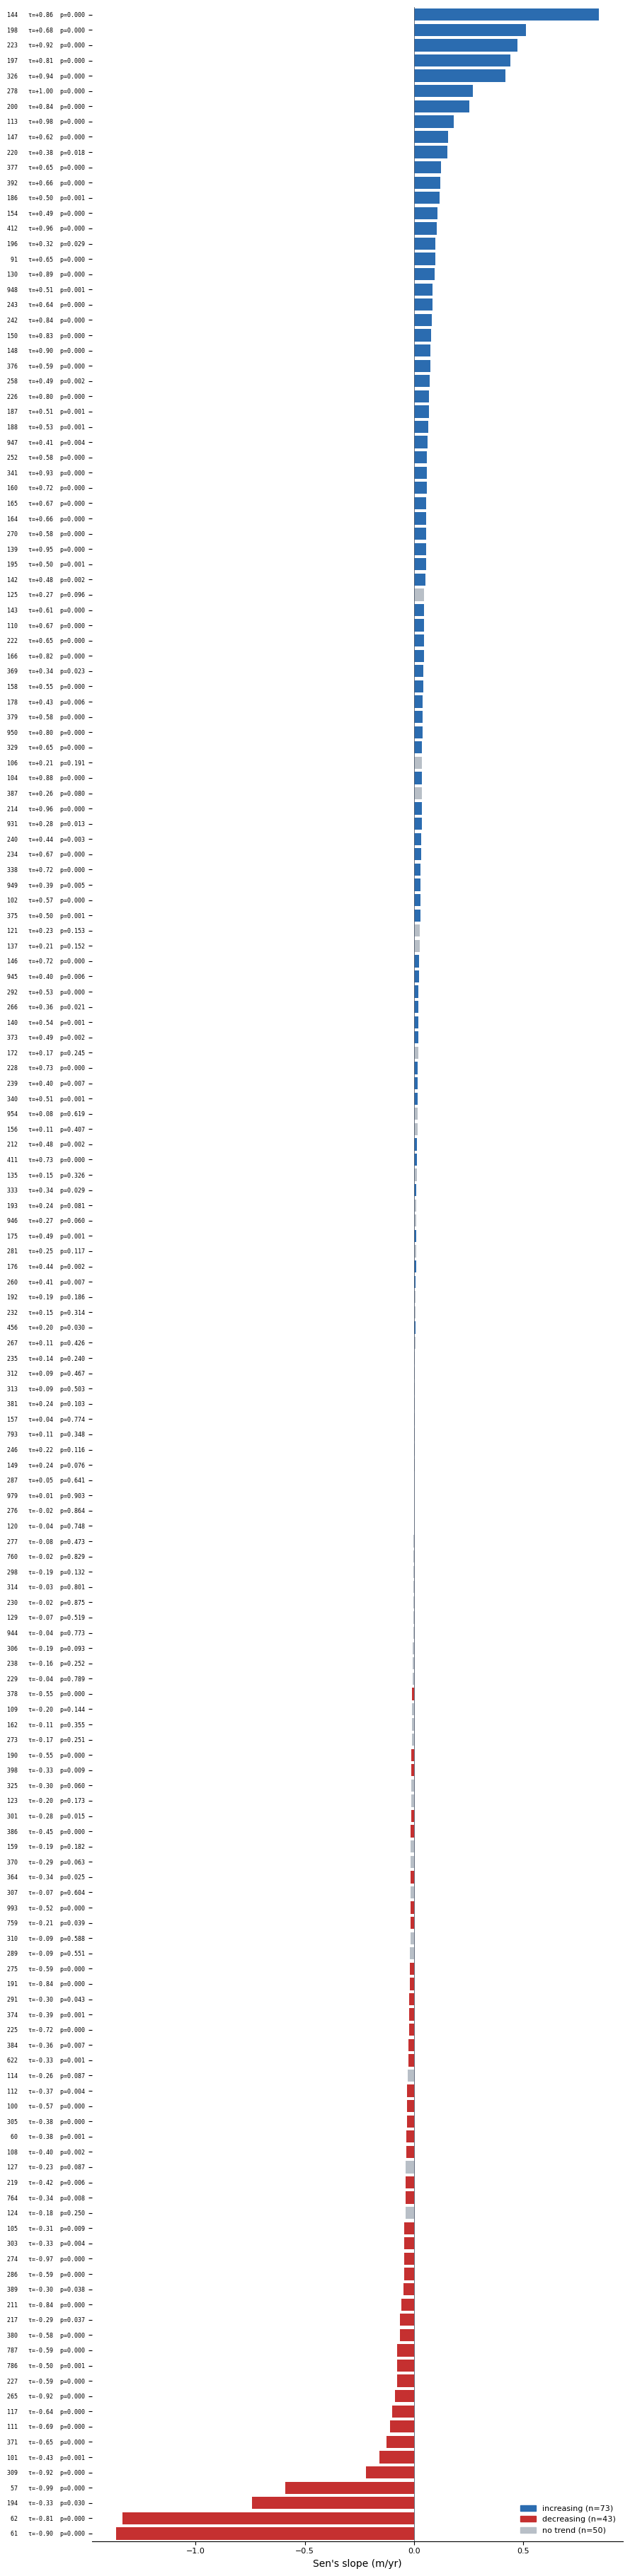

In [61]:
d = smk.sort_values("slope_m_yr")          # ascending: declines at bottom, rises at top

colors = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#b8bfc7"}
bar_c = [colors[v] for v in d["verdict"]]

# station ID + stats folded into the y-label, so the bar itself stays a clean slope
labels = [f"{w}   τ={d.loc[w,'tau']:+.2f}  p={d.loc[w,'p']:.3f}" for w in d.index]

n = len(d)
fig, ax = plt.subplots(figsize=(9, n*0.22))
ax.barh(range(n), d["slope_m_yr"], color=bar_c, edgecolor="none")
ax.axvline(0, lw=0.6, color="#4a5568")

ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=6, fontfamily="monospace")
ax.set_ylim(-0.5, n-0.5)
ax.set_xlabel("Sen's slope (m/yr)")
ax.tick_params(axis="x", labelsize=8)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)

# legend with counts
from matplotlib.patches import Patch
counts = d["verdict"].value_counts()
handles = [Patch(color=colors[v], label=f"{v} (n={counts.get(v,0)})")
           for v in ("increasing", "decreasing", "no trend")]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8)

plt.tight_layout()
# fig.savefig("smk_results.pdf", bbox_inches="tight")
plt.show()

In [62]:
df_m.columns = df_m.columns.astype(int)

In [63]:
order = smk.sort_values("slope_m_yr").index          # declines first
tnum = np.arange(len(df_m))                          # month counter for the line
tmed = np.median(tnum)

vcolor = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#718096"}

with PdfPages("smk_per_well.pdf") as pdf:
    for w in order:
        y = df_m[w]
        slope_mo = smk.loc[w, "slope_m_yr"] / 12       # back to per-month for plotting
        ymed = y.median()
        line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

        v = smk.loc[w, "verdict"]
        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.plot(df_m.index, y, lw=0.7, color="#2d3748")
        ax.plot(df_m.index, line, lw=1.8, color=vcolor[v])

        ax.set_title(
            f"{w}    Sen {smk.loc[w,'slope_m_yr']:+.3f} m/yr    "
            f"τ={smk.loc[w,'tau']:+.2f}    p={smk.loc[w,'p']:.3f}    {v}",
            fontsize=10, color=vcolor[v])
        ax.set_ylabel("WLE (m)", fontsize=8)
        ax.tick_params(labelsize=8)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

## Bow Valley

In [64]:
ws = [931, 301, 303, 386, 305, 764, 760, 759, 364]

In [65]:
harm.index = pd.to_numeric(harm.index)

In [66]:
harm.loc[ws]

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
931,0.028280,0.013778,1.982650,-3.091619,7.0,0.506714,0.693901,4.947629e-22,2.857251
301,-0.011955,0.006489,0.965901,2.957140,7.0,0.469065,0.342782,6.304709e-22,2.817828
303,-0.052018,0.024593,4.387810,-2.778420,8.0,0.602158,1.082415,6.646951e-37,4.053721
386,-0.011541,0.002526,0.542568,-2.942180,7.0,0.383372,0.148541,1.508083e-34,3.652650
305,-0.026907,0.013356,2.658997,-3.094859,7.0,0.132949,1.027427,8.853494e-27,2.588015
764,-0.050812,0.017576,2.617959,-2.542617,8.0,0.552079,0.828701,2.667479e-25,3.159111
760,-0.000276,0.008394,1.762000,-2.889749,7.0,0.554210,0.395364,8.616124e-42,4.456648
759,-0.017977,0.011985,1.521539,-2.913995,7.0,0.615217,0.513790,5.409710e-23,2.961406
364,-0.010140,0.005275,0.182780,-2.950048,7.0,0.836301,0.141396,3.231174e-09,1.292680


In [67]:
df.columns = df.columns.astype(int)

In [68]:
peaks = df.apply(lambda c: c.groupby(df.index.year).idxmax())
peaks[ws]

,931,301,303,386,305,764,760,759,364
date,,,,,,,,,
2005,2005-06-23,2005-06-21,2005-07-04,2005-06-08,2005-06-08,2005-06-28,2005-06-24,2005-06-20,2005-06-22
2006,2006-06-25,2006-06-18,2006-06-20,2006-06-18,2006-06-15,2006-07-05,2006-06-17,2006-06-18,2006-06-19
2007,2007-06-26,2007-06-18,2007-06-20,2007-06-07,2007-06-19,2007-06-29,2007-06-08,2007-06-20,2007-06-22
2008,2008-06-03,2008-06-11,2008-05-26,2008-06-13,2008-06-04,2008-06-22,2008-07-05,2008-06-14,2008-05-28
2009,2009-06-24,2009-05-30,2009-05-30,2009-06-16,2009-05-30,2009-07-06,2009-06-19,2009-06-19,2009-08-16
2010,2010-06-28,2010-06-17,2010-06-20,2010-06-18,2010-06-17,2010-07-04,2010-06-21,2010-06-19,2010-06-21
2011,2011-06-09,2011-06-01,2011-06-02,2011-06-20,2011-06-17,2011-06-25,2011-06-24,2011-05-29,2011-05-30
2012,2012-06-18,2012-06-09,2012-06-12,2012-06-07,2012-06-06,2012-07-05,2012-06-08,2012-06-12,2012-06-29
2013,2013-06-24,2013-06-21,2013-06-21,2013-06-21,2013-06-20,2013-06-30,2013-06-22,2013-06-23,2013-07-03


In [69]:
def circ_mean_doy(days, period=365.25):
    ang = 2*np.pi * np.asarray(days) / period
    m = np.angle(np.exp(1j*ang).mean())
    return (m % (2*np.pi)) / (2*np.pi) * period

peak_doy = df.apply(
    lambda c: circ_mean_doy(c.groupby(df.index.year).idxmax().dt.dayofyear.values)
)
peak_doy = peak_doy.round(0)

In [70]:
peak_doy[ws]

931    171.0
301    155.0
303    166.0
386    164.0
305    158.0
764    187.0
760    167.0
759    163.0
364    165.0
dtype: float64

In [71]:
peak_doy_harm = ((harm["phase_rad"] % (2*np.pi)) / (2*np.pi) * 365.25).round(0)

In [72]:
peak_doy_harm[ws]

931    186.0
301    172.0
303    204.0
386    194.0
305    185.0
764    217.0
760    197.0
759    196.0
364    194.0
Name: phase_rad, dtype: float64

In [73]:
def doy_to_date(doy, year=2021):
    return pd.Timestamp(f"{year}-01-01") + pd.Timedelta(days=float(doy) - 1)

In [87]:
for name, stream in streams.items():
    c = stream.groupby(stream.index.year).idxmax().dt.dayofyear.values
    peak_dates = doy_to_date(circ_mean_doy(c))
    peak_month = peak_dates.month
    peak_label = peak_dates.strftime("%b %d")
    print(f"{name}: {peak_label}")

krns: Jun 01
bl: Jun 04
lkl: Oct 17
brac_e: Jun 01
brab: Jun 03
brac: Jun 04


In [74]:
peak_dates = peak_doy.apply(lambda d: doy_to_date(d))
peak_month = peak_dates.dt.month
peak_label = peak_dates.dt.strftime("%b %d")

In [76]:
peak_label[ws]

931    Jun 20
301    Jun 04
303    Jun 15
386    Jun 13
305    Jun 07
764    Jul 06
760    Jun 16
759    Jun 12
364    Jun 14
dtype: object

In [77]:
peak_dates = peak_doy_harm.apply(lambda d: doy_to_date(d))
peak_month = peak_dates.dt.month
peak_label = peak_dates.dt.strftime("%b %d")
peak_label[ws]

931    Jul 05
301    Jun 21
303    Jul 23
386    Jul 13
305    Jul 04
764    Aug 05
760    Jul 16
759    Jul 15
364    Jul 13
Name: phase_rad, dtype: object